# Section 4 - Run quantum circuits

## Certification weight: 15%

## Objectives 
- Demonstrate an understanding of execution modes such as: session with dedicated, priority, and batch mode
- Demonstrate understanding of how to run quantum circuits with real hardware using Qiskit Runtime primitives and applying broadcasting rules

In [ ]:
https://quantum.cloud.ibm.com/docs/en/guides/choose-execution-mode 

## Execution modes

- job: the simplest:
    - schedule a simple job. It should run quickly
    - use it to submit a single primitive (sampler/estimator) request
- batch:
    - the joblist will be scheduled together, no queue time between them. Some parallelization can be done. It's possible to get the result of all jobs. All jobs are independant
    - use it to submit multiple primitive jobs
- session:
    - same as a batch job, but with a dedicated QPU
    - use it for iterative workloads, that has to be scheduled on the same QPU
    - sessions are more expensive than batches, and not available for open plans

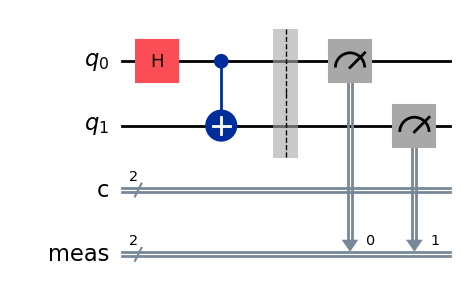

In [54]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = FakeFez()
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)

qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()
qc.draw("mpl")


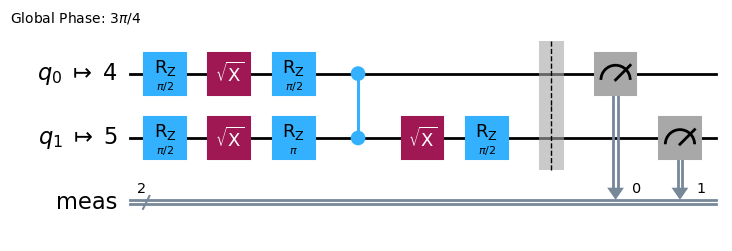

In [55]:
circuit = pm.run(qc)
circuit.draw("mpl")

In [56]:
sampler = Sampler(mode=backend)
job = sampler.run([circuit])

#result = job.result()

In [57]:
result

SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>), meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})

In [58]:
result = job.result()[0]
result.data.meas.get_counts()

{'00': 507, '11': 503, '10': 9, '01': 5}

## (bonus) Access real systems!

Execute this cell first to store in the home directory the API key and the CRN, and avoid providing it later:

In [25]:
your_api_key = "XXX"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:XXX::"

from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="qiskit-graour-com",
    overwrite=True
)

Once the credentials saved, it's possible to load it using `QiskitRuntimeService(name="<name>")`

In [59]:
# Check that the account has been saved properly
service = QiskitRuntimeService(name="qiskit-graour-com")
#service.saved_accounts()
backend = service.least_busy(operational=True, simulator=False)
print(f"We are using the {backend.name} quantum computer")

We are using the ibm_marrakesh quantum computer


## Batches

Imagine we have many circuits to simulate, it's possible to submit all circuits in one job, instead of creating a job per circuit

In [61]:
import numpy as np
from qiskit.circuit import Parameter

qc = QuantumCircuit(1)
phi = Parameter("φ")
qc.rz(phi, 0)
qc.measure_all()

# Sets values:
phi_params = [0, np.pi/2, 1]

# Create circuits to simulate later:
circuits = []
for param in phi_params:
    circuits.append(qc.assign_parameters({phi : param}))
    # Append: we add the circuit in the list

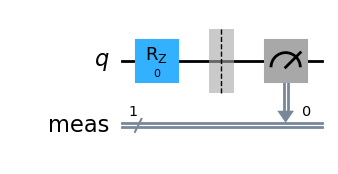

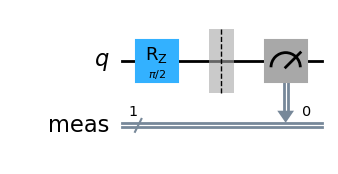

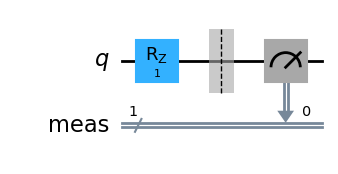

In [62]:
for circuit in circuits:
    display(circuit.draw("mpl"))

In [63]:
# Transpile the circuits
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
trans_circuits = [pm.run(circuit) for circuit in circuits]

In [64]:
from qiskit_ibm_runtime import Batch
import time 
with Batch(backend=backend, max_time="3m") as batch_job:
    sampler = Sampler()
    job1 = sampler.run([trans_circuits[0]], shots=1024)
    job2 = sampler.run([trans_circuits[1]], shots=1024)
    job3 = sampler.run([trans_circuits[2]], shots=1024)


    result_test = job2.result() 
    print(result_test)
    time.sleep(30)
    
    jobx = [sampler.run([circuit_sim], shots=1024) for circuit_sim in trans_circuits]
    job_detail = batch_job.details()
    print(f"Batch session id: {batch_job.session_id}")


PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-05-07 07:30:40', stop='2026-05-07 07:30:41', size=1024>)])}, 'version': 2})
Batch session id: 9fa486f9-bf84-4734-bbcd-8781be57a341


In [40]:
print(f"Result1: {job1.result()}")
print(f"Result2: {job2.result()}")
print(f"Result3: {job3.result()}")
print(f"ResultX: {jobx }")

Result1: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-04-16 16:03:47', stop='2026-04-16 16:03:48', size=1024>)])}, 'version': 2})
Result2: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-04-16 16:03:49', stop='2026-04-16 16:03:51', size=1024>)])}, 'version': 2})
Result3: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-04-16 16:03:48', stop='2026-04-16 16:03:49', size=1024>)])}, 'version': 2})
ResultX: [<RuntimeJobV2('d7gggorjne2c7392rsgg', 'sampler')>, 

In [41]:
result1 = job1.result()
result1[0].data.meas.get_counts()

{'0': 1004, '1': 20}

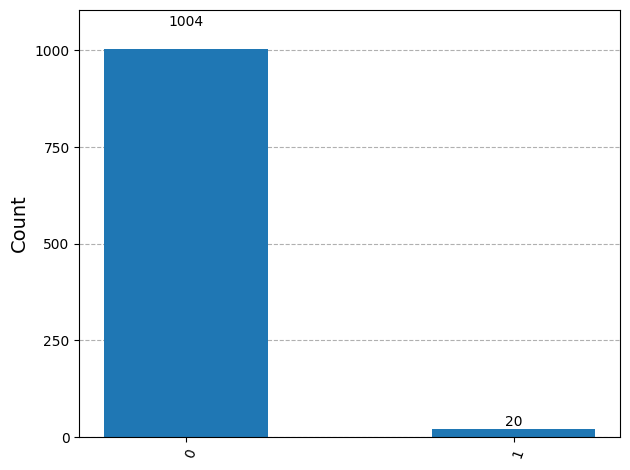

In [43]:
from qiskit.visualization import plot_histogram
plot_histogram(result1[0].data.meas.get_counts())

In [44]:
resultx0 = jobx[0].result()
countsx0 = resultx0[0].data.meas.get_counts()

In [45]:
countsx0

{'0': 1009, '1': 15}

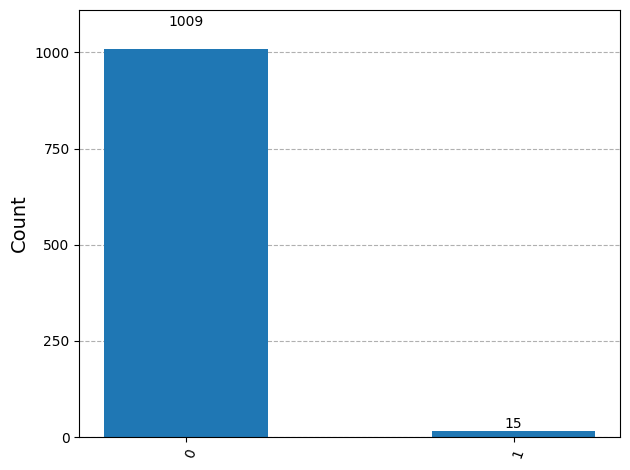

In [46]:
plot_histogram(countsx0)

In [48]:
job_detail

{'id': '1ca86010-dd3b-4677-a1bd-248dd1a83745',
 'backend_name': 'ibm_marrakesh',
 'interactive_timeout': 1,
 'max_time': 180,
 'active_timeout': 180,
 'state': 'active',
 'accepting_jobs': True,
 'last_job_started': '2026-04-16T16:24:48.577Z',
 'last_job_completed': None,
 'started_at': '2026-04-16T16:24:44.364Z',
 'closed_at': None,
 'activated_at': '2026-04-16T16:24:44.364Z',
 'mode': 'batch',
 'usage_time': None}

## Sessions
Same construction as batches, but using `with session`.

In [ ]:
from qiskit_ibm_runtime import Session
with Session(backend=backend, max_time="25m"):
    <job>